In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn import tree
import matplotlib.pyplot as plt


In [2]:
data = pd.read_csv(
    r"C:\Users\durga\Downloads\Data Set For Task-20260526T161503Z-3-001\Data Set For Task\4) house Prediction Data Set.csv",
    sep=r"\s+",
    header=None
)

In [3]:
columns = [
    "CRIM","ZN","INDUS","CHAS","NOX","RM","AGE",
    "DIS","RAD","TAX","PTRATIO","B","LSTAT","PRICE"
]

data.columns = columns

In [4]:
median_price = data["PRICE"].median()

data["PRICE_CLASS"] = data["PRICE"].apply(
    lambda x: 1 if x > median_price else 0
)

In [5]:
X = data.drop(["PRICE", "PRICE_CLASS"], axis=1)
y = data["PRICE_CLASS"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [8]:
y_pred = model.predict(X_test)

In [9]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.8823529411764706

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.88      0.90        60
           1       0.84      0.88      0.86        42

    accuracy                           0.88       102
   macro avg       0.88      0.88      0.88       102
weighted avg       0.88      0.88      0.88       102



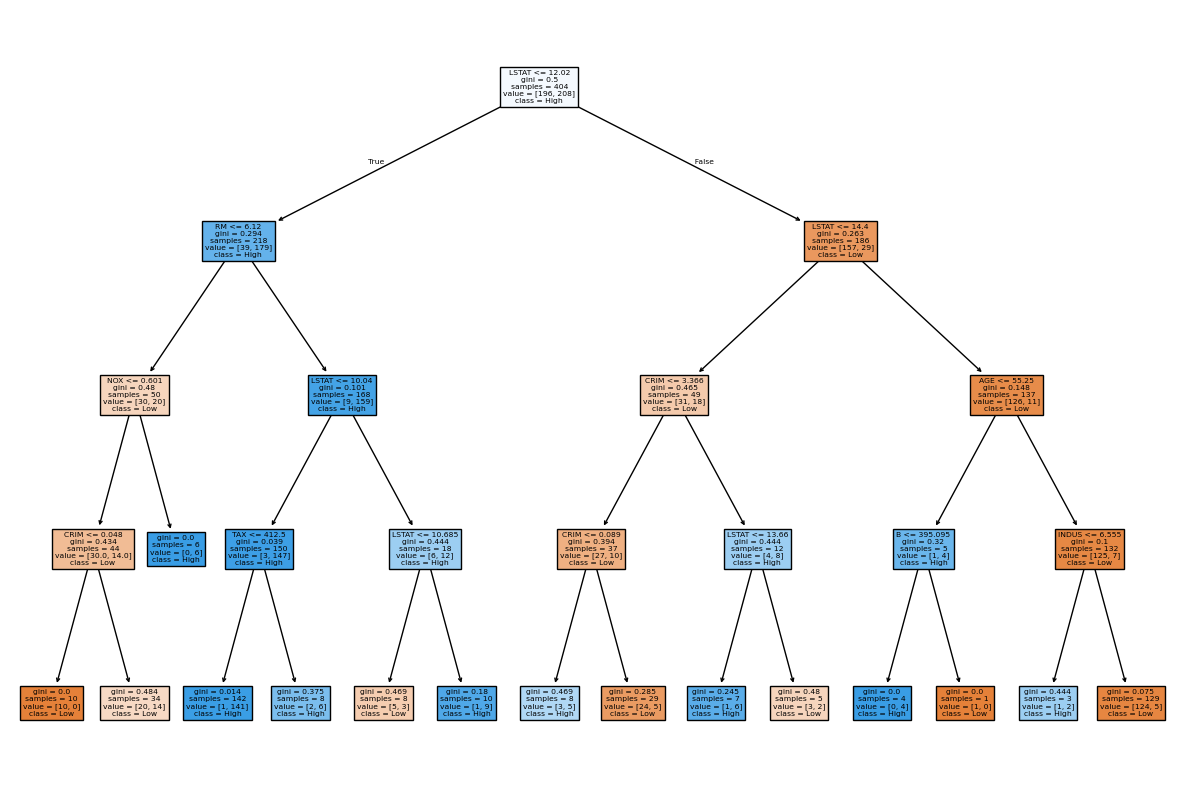

In [10]:
plt.figure(figsize=(15,10))
tree.plot_tree(model, feature_names=X.columns, class_names=["Low", "High"], filled=True)
plt.show()